In [3]:
import pandas as pd
import seaborn as sns

# Load the built-in NYC taxi dataset
print("Loading dataset...")
df = sns.load_dataset('taxis')

# Show the first 5 rows to see what it looks like
print("Dataset loaded successfully!")
df.head()


Loading dataset...
Dataset loaded successfully!


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [4]:
# 1. Check how many rows and columns we have
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.\n")

# 2. Look at the column names, data types, and check for missing values
df.info()


Dataset has 6433 rows and 14 columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes

In [5]:
print("Cleaning data...")

# 1. Drop any rows that have missing (NaN) values
df_cleaned = df.dropna()

# 2. Keep only trips that actually traveled a distance and cost money
df_cleaned = df_cleaned[(df_cleaned['distance'] > 0) & (df_cleaned['fare'] > 0)]

print(f"Old number of rows: {df.shape[0]}")
print(f"New number of rows: {df_cleaned.shape[0]}")
print("\nData cleaned successfully! 🧹")


Cleaning data...
Old number of rows: 6433
New number of rows: 6309

Data cleaned successfully! 🧹


In [6]:
# 1. Extract the hour (0-23) and the day of the week (Monday, Tuesday, etc.)
df_cleaned['pickup_hour'] = df_cleaned['pickup'].dt.hour
df_cleaned['pickup_day'] = df_cleaned['pickup'].dt.day_name()

# 2. Calculate trip duration in minutes
df_cleaned['duration_minutes'] = (df_cleaned['dropoff'] - df_cleaned['pickup']).dt.total_seconds() / 60

print("New features created! 🎉")
df_cleaned[['pickup', 'pickup_hour', 'pickup_day', 'duration_minutes']].head()


New features created! 🎉


,pickup,pickup_hour,pickup_day,duration_minutes
0,2019-03-23 20:21:09,20,Saturday,6.250000
1,2019-03-04 16:11:55,16,Monday,7.083333
2,2019-03-27 17:53:01,17,Wednesday,7.400000
3,2019-03-10 01:23:59,1,Sunday,25.866667
4,2019-03-30 13:27:42,13,Saturday,9.533333


Graph 1: Rides per Day


/var/folders/ll/0kbx4vc155nb_2g6qvg77lr80000gn/T/ipykernel_80434/2979143411.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='pickup_day',


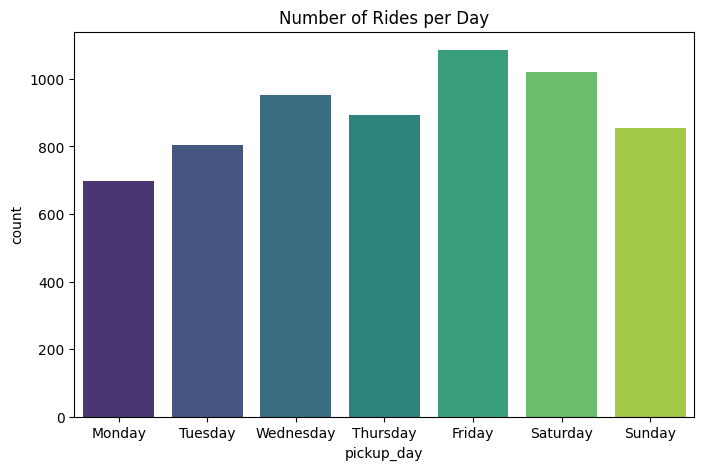

Graph 2: Average Fare by Hour


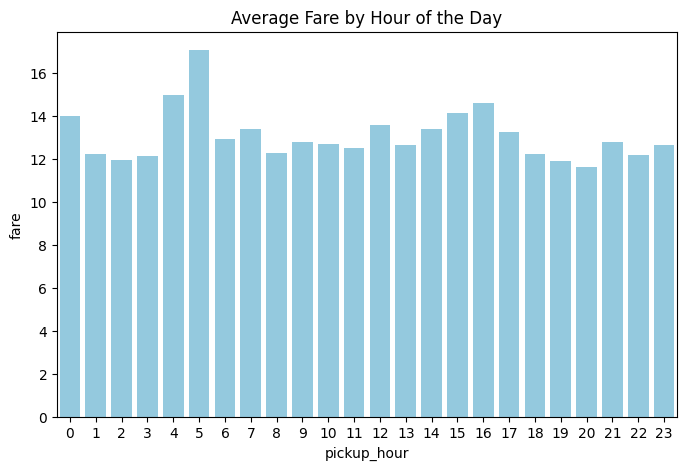

Graph 3: Payment Methods


/var/folders/ll/0kbx4vc155nb_2g6qvg77lr80000gn/T/ipykernel_80434/2979143411.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='payment', palette='Set2')


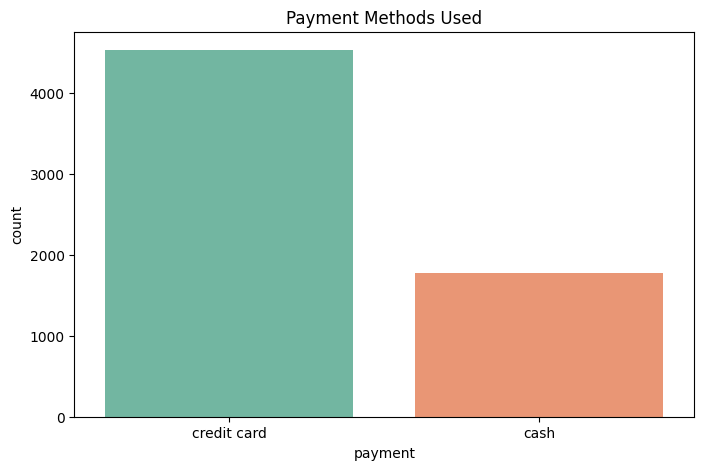

In [7]:
import matplotlib.pyplot as plt

# Tell Jupyter to show graphs nice and large
plt.rcParams['figure.figsize'] = (8, 5)

# Graph 1: Which day has the most rides?
print("Graph 1: Rides per Day")
sns.countplot(data=df_cleaned, x='pickup_day', 
              order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], 
              palette='viridis')
plt.title('Number of Rides per Day')
plt.show()

# Graph 2: How does the average fare change by hour?
print("Graph 2: Average Fare by Hour")
sns.barplot(data=df_cleaned, x='pickup_hour', y='fare', color='skyblue', errorbar=None)
plt.title('Average Fare by Hour of the Day')
plt.show()

# Graph 3: How do people pay?
print("Graph 3: Payment Methods")
sns.countplot(data=df_cleaned, x='payment', palette='Set2')
plt.title('Payment Methods Used')
plt.show()


## UrbanRoute Taxi Insights 🚕

Based on our exploratory data analysis, here are our key findings:
1. **Busiest Day:** Friday has the highest number of rides, likely due to people going out for the weekend.
2. **Peak Fares:** Fares seem highest in the very early morning hours (around 4 AM to 5 AM), possibly due to airport trips or lack of traffic allowing longer distances.
3. **Payments:** Credit Cards are overwhelmingly the preferred payment method compared to cash.


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

print("Training Machine Learning Model... 🤖")

# 1. We will try to predict the fare (y) using the distance and the duration (X)
X = df_cleaned[['distance', 'duration_minutes']]
y = df_cleaned['fare']

# 2. Split the data so the model can learn on 80% and we test it on the remaining 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create the model and train it!
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Check how good it is (100% is a perfect score)
score = model.score(X_test, y_test)
print(f"Model Prediction Accuracy Score: {score * 100:.2f}%")


Training Machine Learning Model... 🤖
Model Prediction Accuracy Score: 96.80%
